# Defect Detection in Image (Crack and Hole)
This notebook processes an image to detect defects such as cracks and holes.

(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

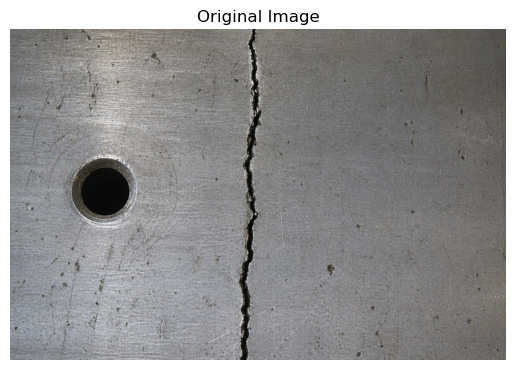

In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("IMAGE 2026-04-29 11:11:15.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

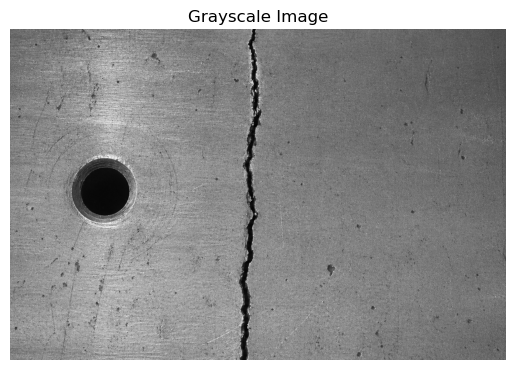

In [3]:

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

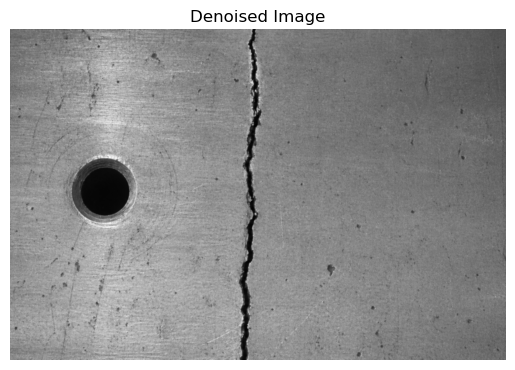

In [4]:

# Denoise using Gaussian Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Denoised Image")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

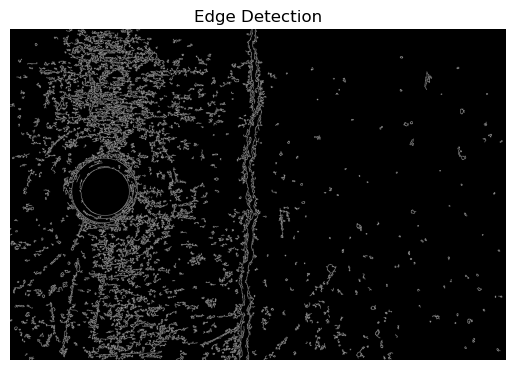

In [5]:

# Edge detection using Canny
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

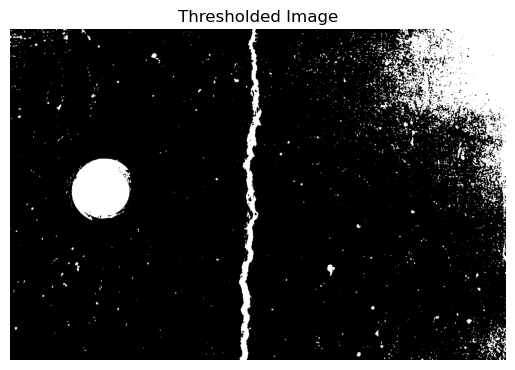

In [6]:

# Thresholding
_, thresh = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

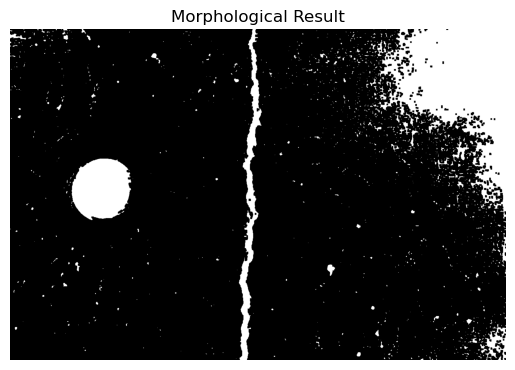

In [7]:

# Morphological operations to clean up
kernel = np.ones((3,3), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.imshow(morph, cmap='gray')
plt.title("Morphological Result")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

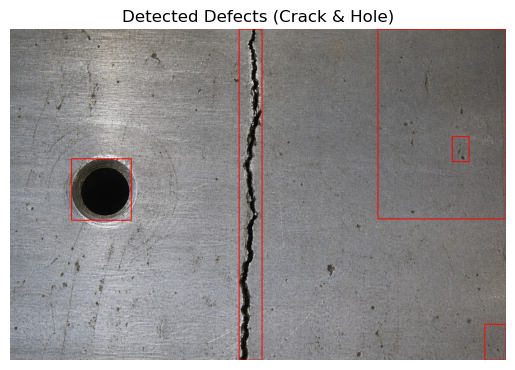

In [ ]:

# Find contours (defects)
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = img_rgb.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 500:  # filter small noise
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(result, (x,y), (x+w, y+h), (255,0,0), 2)

plt.imshow(result)
plt.title("Detected Defects (Crack & Hole)")
plt.axis('off')
